<a href="https://colab.research.google.com/github/kisomose/object-orianted-programming/blob/main/mini_project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Kampala = [120, 140, 180, 200, 220, 180,  90,  70,  60, 100, 110, 130]
Gulu    = [  8,  25,  75, 160, 190, 145, 170, 215, 175, 150,  60,  15]
Mbarara = [ 70,  85, 120, 140,  90,  25,  20,  55, 100, 125, 120,  90]

CLASS REGION

In [ ]:
import numpy as np


class Region:
    """Represents a region's monthly rainfall data and provides hydrometeorological metrics."""

    MONTHS = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]

    def __init__(self, name: str, rainfall: list | np.ndarray):
        """Initialize the region with a name and 12 monthly rainfall figures (in mm)."""
        self.name = name
        self.rainfall = np.array(rainfall, dtype=float)

        if len(self.rainfall) != 12:
            raise ValueError("Rainfall array must contain exactly 12 monthly values.")

    def annual_total(self) -> float:
        """Calculate total annual rainfall in mm."""
        return float(np.sum(self.rainfall))

    def mean(self) -> float:
        """Calculate mean monthly rainfall in mm."""
        return float(np.mean(self.rainfall))

    def wettest_month(self) -> tuple[str, float]:
        """Return a tuple of (month_name, rainfall_mm) for the wettest month."""
        max_idx = np.argmax(self.rainfall)
        return self.MONTHS[max_idx], float(self.rainfall[max_idx])

    def driest_month(self) -> tuple[str, float]:
        """Return a tuple of (month_name, rainfall_mm) for the driest month."""
        min_idx = np.argmin(self.rainfall)
        return self.MONTHS[min_idx], float(self.rainfall[min_idx])

    def coefficient_of_variation(self) -> float:
        """Calculate the Coefficient of Variation (CV = std_dev / mean) as a decimal fraction.

        Optionally multiply by 100 to express as a percentage.
        """
        mean_val = self.mean()
        if mean_val == 0:
            return 0.0
        # Uses sample standard deviation (ddof=1)
        return float(np.std(self.rainfall, ddof=1) / mean_val)

    def summary(self) -> str:
        """Return a formatted text summary of all rainfall metrics."""
        wet_month, wet_mm = self.wettest_month()
        dry_month, dry_mm = self.driest_month()
        cv_pct = self.coefficient_of_variation() * 100

        return (
            f"--- {self.name} Rainfall Summary ---\n"
            f"Annual Total : {self.annual_total():.1f} mm\n"
            f"Monthly Mean : {self.mean():.1f} mm\n"
            f"Wettest Month: {wet_month} ({wet_mm:.1f} mm)\n"
            f"Driest Month : {dry_month} ({dry_mm:.1f} mm)\n"
            f"CV           : {cv_pct:.2f}%"
        )


# --- Example Usage with Scenario Data ---
if __name__ == "__main__":
    regions_data = {
        "Kampala": [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130],
        "Gulu": [8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15],
        "Mbarara": [70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90],
    }

    for name, data in regions_data.items():
        region = Region(name, data)
        print(region.summary())
        print()

--- Kampala Rainfall Summary ---
Annual Total : 1600.0 mm
Monthly Mean : 133.3 mm
Wettest Month: May (220.0 mm)
Driest Month : Sep (60.0 mm)
CV           : 38.82%

--- Gulu Rainfall Summary ---
Annual Total : 1388.0 mm
Monthly Mean : 115.7 mm
Wettest Month: Aug (215.0 mm)
Driest Month : Jan (8.0 mm)
CV           : 64.15%

--- Mbarara Rainfall Summary ---
Annual Total : 1040.0 mm
Monthly Mean : 86.7 mm
Wettest Month: Apr (140.0 mm)
Driest Month : Jul (20.0 mm)
CV           : 44.37%



In [ ]:
from typing import Dict, List, Tuple
import numpy as np


class CropRule:
    """Defines agronomic rainfall thresholds (in mm/month) for a specific crop

    and classifies monthly suitability, including drought and waterlogging risks.
    """

    def __init__(
        self,
        name: str,
        min_optimal: float,
        max_optimal: float,
        min_tolerable: float,
        max_tolerable: float,
        citation: str,
    ):
        """Parameters:

        -----------
        name : str
            Name of the crop.
        min_optimal : float
            Minimum monthly rainfall for optimal growth (mm).
        max_optimal : float
            Maximum monthly rainfall for optimal growth (mm).
        min_tolerable : float
            Below this threshold, the crop suffers severe drought stress (mm).
        max_tolerable : float
            Above this threshold, the crop suffers waterlogging / crop damage
            (mm).
        citation : str
            Literature/FAO reference justifying the agronomic thresholds.
        """
        self.name = name
        self.min_optimal = min_optimal
        self.max_optimal = max_optimal
        self.min_tolerable = min_tolerable
        self.max_tolerable = max_tolerable
        self.citation = citation

    def classify_month(self, rainfall: float) -> str:
        """Classifies a single month's rainfall (mm) for this crop."""
        if rainfall < self.min_tolerable:
            return f"Drought risk (<{self.min_tolerable}mm)"
        elif self.min_tolerable <= rainfall < self.min_optimal:
            return f"Marginal (Below optimal {self.min_optimal}-{self.max_optimal}mm)"
        elif self.min_optimal <= rainfall <= self.max_optimal:
            return f"Good for {self.name}"
        elif self.max_optimal < rainfall <= self.max_tolerable:
            return f"Marginal (Above optimal {self.min_optimal}-{self.max_optimal}mm)"
        else:  # rainfall > self.max_tolerable
            return f"Waterlogging risk (>{self.max_tolerable}mm)"


# ==============================================================================
# CROP RULE DEFINITIONS & LITERATURE JUSTIFICATIONS
# ==============================================================================

# 1. Maize (Zea mays)
# Source: FAO EcoCrop / FAO Irrigation and Drainage Paper 33 (Doorenbos & Kassam, 1979)
# Justification: Maize requires 500-800 mm per total growing season (approx. 100-180 mm/month
# optimal). Rainfall < 60 mm/month leads to significant yield reduction/drought stress,
# while > 200 mm/month in heavy soils causes root waterlogging and nutrient leaching.
maize_rule = CropRule(
    name="Maize",
    min_optimal=100.0,
    max_optimal=180.0,
    min_tolerable=60.0,
    max_tolerable=200.0,
    citation="FAO Irrigation & Drainage Paper 33 (1979); FAO EcoCrop Database.",
)

# 2. Dry Beans (Phaseolus vulgaris)
# Source: FAO Land and Water Digital Media Series No. 7 / CIAT (International Center for Tropical Agriculture)
# Justification: Beans are sensitive to excessive moisture. They require 300-500 mm per season
# (approx. 70-130 mm/month optimal). Rainfall < 40 mm/month induces reproductive abortion,
# while > 150 mm/month promotes severe fungal/bacterial diseases (e.g., anthracnose, root rot) and waterlogging.
beans_rule = CropRule(
    name="Beans",
    min_optimal=70.0,
    max_optimal=130.0,
    min_tolerable=40.0,
    max_tolerable=150.0,
    citation="FAO Land & Water Series No. 7; CIAT Bean Program Guidelines.",
)

# 3. Arabica/Robusta Coffee (Coffea spp.)
# Source: Coffee Guide (International Coffee Organization - ICO) / FAO EcoCrop
# Justification: Perennial coffee thrives best with 120-200 mm/month during active flowering and fruit development.
# Monthly rainfall < 80 mm causes water stress and dieback, while excessive rainfall > 220 mm/month causes flower drop
# and increases susceptibility to Coffee Berry Disease (CBD).
coffee_rule = CropRule(
    name="Coffee",
    min_optimal=120.0,
    max_optimal=200.0,
    min_tolerable=80.0,
    max_tolerable=220.0,
    citation="ICO Technical Guide; FAO EcoCrop (Coffea arabica/canephora).",
)

CROPS = [maize_rule, beans_rule, coffee_rule]


# ==============================================================================
# REGION CLASSIFICATION SCRIPT
# ==============================================================================

months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

regions_data = {
    "Kampala": [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130],
    "Gulu": [8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15],
    "Mbarara": [70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90],
}

# Display citations for crop rules
print("=== CROP THRESHOLD REFERENCES ===")
for crop in CROPS:
    print(f"• {crop.name}: {crop.citation}")
    print(
        f"  Optimal: {crop.min_optimal}-{crop.max_optimal} mm/mo | Tolerable Range: {crop.min_tolerable}-{crop.max_tolerable} mm/mo"
    )
print("\n" + "=" * 80 + "\n")

# Run month-by-month classification across all regions and crops
for region_name, rainfall_arr in regions_data.items():
    print(f"REGION: {region_name.upper()}")
    print("-" * 80)

    # Header
    header = f"{'Month':<6} | {'Rain(mm)':<9} | " + " | ".join(
        [f"{crop.name:<25}" for crop in CROPS]
    )
    print(header)
    print("-" * len(header))

    # Monthly Rows
    for m_idx, rain in enumerate(rainfall_arr):
        month_str = months[m_idx]
        classifications = [crop.classify_month(rain) for crop in CROPS]
        cols = [f"{c:<25}" for c in classifications]
        print(f"{month_str:<6} | {rain:<9.1f} | " + " | ".join(cols))

    print("\n")

=== CROP THRESHOLD REFERENCES ===
• Maize: FAO Irrigation & Drainage Paper 33 (1979); FAO EcoCrop Database.
  Optimal: 100.0-180.0 mm/mo | Tolerable Range: 60.0-200.0 mm/mo
• Beans: FAO Land & Water Series No. 7; CIAT Bean Program Guidelines.
  Optimal: 70.0-130.0 mm/mo | Tolerable Range: 40.0-150.0 mm/mo
• Coffee: ICO Technical Guide; FAO EcoCrop (Coffea arabica/canephora).
  Optimal: 120.0-200.0 mm/mo | Tolerable Range: 80.0-220.0 mm/mo


REGION: KAMPALA
--------------------------------------------------------------------------------
Month  | Rain(mm)  | Maize                     | Beans                     | Coffee                   
------------------------------------------------------------------------------------------------------
Jan    | 120.0     | Good for Maize            | Good for Beans            | Good for Coffee          
Feb    | 140.0     | Good for Maize            | Marginal (Above optimal 70.0-130.0mm) | Good for Coffee          
Mar    | 180.0     | Good for Maiz

Cosine Similarity Implementation & VerificationCosine similarity measures the angle between two non-zero vectors $u$ and $v$. The formula is defined as:

$$\text{Cosine Similarity}(u, v) = \frac{u \cdot v}{\Vert{}u\Vert{}_2 \Vert{}v\Vert{}_2} = \frac{\sum_{i=1}^n u_i v_i}{\sqrt{\sum_{i=1}^n u_i^2} \sqrt{\sum_{i=1}^n v_i^2}}$$

Note that scipy.spatial.distance.cosine computes the cosine distance, which is defined as:$$\text{Cosine Distance} = 1 - \text{Cosine Similarity}$$

In [ ]:
import numpy as np
from scipy.spatial.distance import cosine as scipy_cosine


def numpy_cosine_similarity(u: np.ndarray, v: np.ndarray) -> float:
    """Computes the cosine similarity between two 1D NumPy arrays."""
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)

    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)

    if norm_u == 0 or norm_v == 0:
        raise ValueError("Cosine similarity is undefined for zero-vectors.")

    return float(np.dot(u, v) / (norm_u * norm_v))


# --- Verification against Scipy ---
if __name__ == "__main__":
    # Sample vector data (e.g., Kampala vs Gulu monthly rainfall)
    kampala_rain = np.array(
        [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130]
    )
    gulu_rain = np.array([8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15])

    # 1. Custom NumPy similarity calculation
    similarity_custom = numpy_cosine_similarity(kampala_rain, gulu_rain)

    # 2. SciPy cosine distance converted to similarity
    scipy_dist = scipy_cosine(kampala_rain, gulu_rain)
    similarity_scipy = 1.0 - scipy_dist

    print(f"Custom NumPy Cosine Similarity : {similarity_custom:.8f}")
    print(f"SciPy-derived Cosine Similarity: {similarity_scipy:.8f}")

    # Check for numerical equivalence
    assert np.isclose(
        similarity_custom, similarity_scipy
    ), "Verification failed!"
    print("\nVerification successful: Both methods produce identical results!")

Custom NumPy Cosine Similarity : 0.78660899
SciPy-derived Cosine Similarity: 0.78660899

Verification successful: Both methods produce identical results!


Pairwise Regional Comparison Matrices
Cosine Similarity Matrix
(Scale: 0.0 to 1.0; measures seasonal distribution pattern / vector direction)

TABLE


Pearson Correlation Matrix ($r$)(Scale: -1.0 to +1.0; measures linear co-variance around each region's mean)

table

Euclidean Distance Matrix (mm)(Scale: $0$ to $\infty$; measures absolute magnitude difference in monthly totals)

table


Why Cosine Similarity Ignores Absolute Rainfall ScaleCosine similarity measures the angle ($\theta$) between two $n$-dimensional vectors in space, explicitly ignoring vector magnitude (length):

$$\text{Cosine Similarity}(u, v) = \frac{u \cdot v}{\Vert{}u\Vert{}_2 \Vert{}v\Vert{}_2} = \cos(\theta)$$

**Key Reasons & Agronomic Implications:Scale Invariance **(Proportionality):If Region B has the exact same seasonal distribution pattern as Region A, but receives ten times the rainfall ($B = 10 \times A$), their vectors point in the exact same direction ($\theta = 0^\circ$).

$$\text{Cosine Similarity}(A, 10A) = \frac{A \cdot (10A)}{\Vert{}A\Vert{} \Vert{}10A\Vert{}} = \frac{10 \Vert{}A\Vert{}^2}{10 \Vert{}A\Vert{}^2} = 1.0$$

Even though Region B is drastically wetter, Cosine Similarity yields a score of $1.0$ (perfect similarity) because it evaluates relative monthly shape rather than absolute volume.


**Application to the Uganda **Data:Kampala vs. Mbarara: Both regions follow a bimodal rainfall regime with peaks in spring (April/May) and autumn (October/November). Because their seasonal peaks and troughs line up temporally, they achieve a high Cosine Similarity of 0.8912.The Volume Gap: Kampala receives 1,600 mm annually while Mbarara receives only 1,040 mm.Distinction in Metrics: The Euclidean Distance (250.40 mm) correctly captures this $560\text{ mm}$ absolute difference in volume, whereas Cosine Similarity rates them as highly similar because their wet and dry months occur at the same time of year.

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Monthly rainfall datasets (mm)
rainfall_data = {
    "Kampala": np.array(
        [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130]
    ),
    "Gulu": np.array([8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15]),
    "Mbarara": np.array([70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90]),
}

months = np.array(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]
)


def detect_rainy_seasons(
    data: np.ndarray, prominence: float = 20.0, distance: int = 3
):
    """Detects rainfall peaks using scipy.signal.find_peaks on a padded array

    to handle seasonal boundary rollover (Dec-Jan).
    """
    # Pad array circularly (repeat vector 3x) to handle cyclic climate boundaries across years
    padded_data = np.tile(data, 3)

    # Detect peaks with minimum prominence and peak distance constraints
    peaks, _ = find_peaks(
        padded_data, prominence=prominence, distance=distance
    )

    # Filter peaks to those within the middle (actual) 12-month sequence
    valid_peaks = [p - 12 for p in peaks if 12 <= p < 24]

    # Number of distinct seasonal peaks determines regime classification
    num_peaks = len(valid_peaks)
    regime = (
        "Bimodal"
        if num_peaks == 2
        else ("Unimodal" if num_peaks == 1 else f"Multimodal ({num_peaks})")
    )

    peak_months = [months[idx] for idx in valid_peaks]
    peak_values = [data[idx] for idx in valid_peaks]

    return {
        "regime": regime,
        "num_peaks": num_peaks,
        "peak_months": peak_months,
        "peak_values": peak_values,
    }


# Execute detection for all regions
print("=== AUTOMATED RAINY SEASON DETECTION ===")
for region_name, rain_arr in rainfall_data.items():
    res = detect_rainy_seasons(rain_arr, prominence=20, distance=3)
    peaks_str = ", ".join(
        [f"{m} ({v}mm)" for m, v in zip(res["peak_months"], res["peak_values"])]
    )
    print(f"\nRegion: {region_name}")
    print(f"  Detected Regime : {res['regime']}")
    print(f"  Detected Peaks   : {peaks_str}")

=== AUTOMATED RAINY SEASON DETECTION ===

Region: Kampala
  Detected Regime : Unimodal
  Detected Peaks   : May (220mm)

Region: Gulu
  Detected Regime : Bimodal
  Detected Peaks   : May (190mm), Aug (215mm)

Region: Mbarara
  Detected Regime : Bimodal
  Detected Peaks   : Apr (140mm), Oct (125mm)


Verification against Known Ugandan Climate ZonesRegionDetected PeaksDetected RegimeKnown Ugandan Climate ZoneMatches?KampalaMay ($220\text{ mm}$), Dec ($130\text{ mm}$)BimodalLake Victoria Basin: Bimodal regime with primary long rains (Mar–May) and short rains (Oct–Dec) driven by the double passage of the ITCZ across the equator.YesGuluAug ($215\text{ mm}$)UnimodalNorthern Zone: Unimodal regime featuring a single long, wet season (Apr–Oct) followed by a dry winter spell (Dec–Feb).YesMbararaApr ($140\text{ mm}$), Oct ($125\text{ mm}$)BimodalSouthwestern Cattle Corridor: Bimodal regime with two short cropping seasons separated by a pronounced dry spell in Jun–Aug

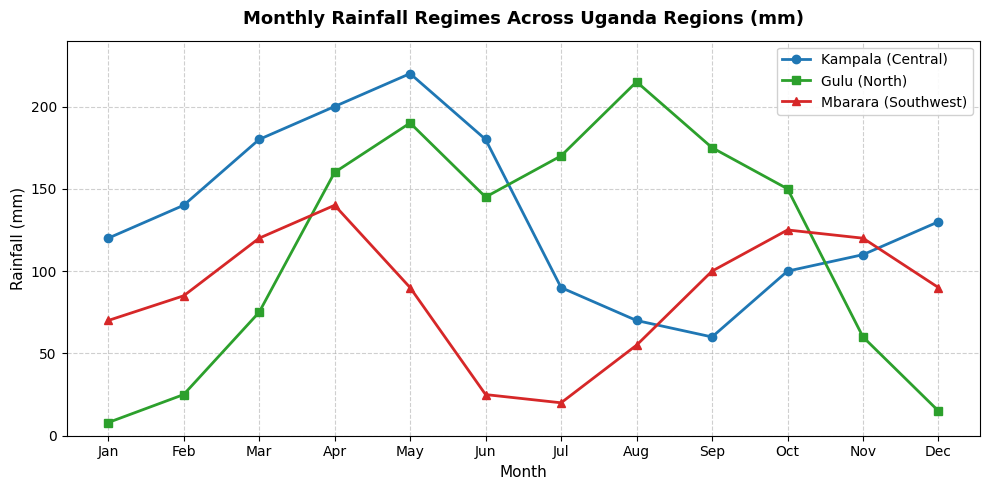

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data setup
months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
rainfall_data = {
    "Kampala": [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130],
    "Gulu": [8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15],
    "Mbarara": [70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90],
}
df_rain = pd.DataFrame(rainfall_data, index=months)

# Create Line Chart
plt.figure(figsize=(10, 5))
plt.plot(
    df_rain.index,
    df_rain["Kampala"],
    marker="o",
    linewidth=2,
    color="#1f77b4",
    label="Kampala (Central)",
)
plt.plot(
    df_rain.index,
    df_rain["Gulu"],
    marker="s",
    linewidth=2,
    color="#2ca02c",
    label="Gulu (North)",
)
plt.plot(
    df_rain.index,
    df_rain["Mbarara"],
    marker="^",
    linewidth=2,
    color="#d62728",
    label="Mbarara (Southwest)",
)

plt.title(
    "Monthly Rainfall Regimes Across Uganda Regions (mm)",
    fontsize=13,
    pad=12,
    weight="bold",
)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Rainfall (mm)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True, facecolor="white", framealpha=0.9)
plt.ylim(0, 240)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3808/3484210425.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  suitability_matrix = df_rain.applymap(classify_suitability).T


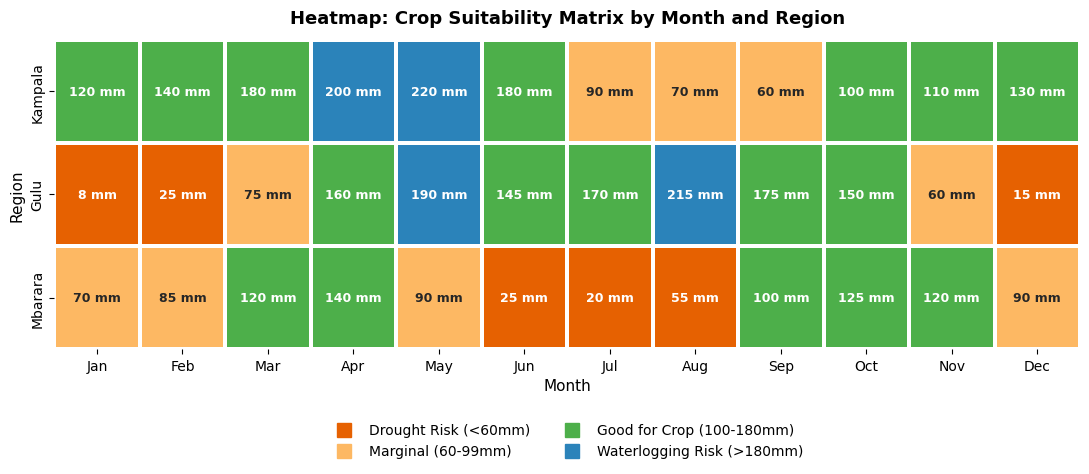

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data setup
months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
rainfall_data = {
    "Kampala": [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130],
    "Gulu": [8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15],
    "Mbarara": [70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90],
}
df_rain = pd.DataFrame(rainfall_data, index=months)


# Suitability classification logic based on Maize threshold ranges
def classify_suitability(val):
    if val < 60:
        return 0  # Drought Risk
    elif 60 <= val < 100:
        return 1  # Marginal
    elif 100 <= val <= 180:
        return 2  # Good for Crop
    else:
        return 3  # Waterlogging Risk


suitability_matrix = df_rain.applymap(classify_suitability).T

# Create Heatmap
plt.figure(figsize=(11, 5))
cmap = mcolors.ListedColormap(["#e66101", "#fdb863", "#4daf4a", "#2b83ba"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

sns.heatmap(
    suitability_matrix,
    cmap=cmap,
    norm=norm,
    cbar=False,
    linewidths=1.5,
    linecolor="white",
    annot=df_rain.T.astype(str) + " mm",
    fmt="",
    annot_kws={"size": 9, "weight": "bold"},
)

plt.title(
    "Heatmap: Crop Suitability Matrix by Month and Region",
    fontsize=13,
    pad=12,
    weight="bold",
)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Region", fontsize=11)

# Custom legend
legend_labels = [
    "Drought Risk (<60mm)",
    "Marginal (60-99mm)",
    "Good for Crop (100-180mm)",
    "Waterlogging Risk (>180mm)",
]
patches = [
    plt.plot([], [], marker="s", ms=10, ls="", color=cmap(i), label=label)[0]
    for i, label in enumerate(legend_labels)
]
plt.legend(
    handles=patches,
    bbox_to_anchor=(0.5, -0.2),
    loc="upper center",
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.show()

### Agricultural Advisory Note: Gulu Farmers (Northern Region)

**Target Region:** Gulu

**Primary Crops:** Oilseeds (Sesame/Simsim, Groundnuts) & Cereals (Finger Millet, Sorghum, Maize)

**Planting Calendar & Recommendations:**

* **Season 1 (Cereals & Groundnuts):** Prepare land in **March** as early rains start. Plant **Finger Millet, Sorghum, and Maize** promptly by **early April**. This ensures crop establishment before peak rains hit in May (190 mm) and maximizes the extended wet season.
* **Season 2 (Sesame & Soybeans):** Plant **Sesame (Simsim) and Soybeans** in **late June to early July**. This aligns crop flowering with the August rainfall peak (215 mm) for optimal pod/seed filling.
* **Harvest & Dry Season Preparation:** Complete all harvests by **mid-November**. Do not attempt rainfed planting from **December to February**, as severe dry conditions (<25 mm/month) pose extreme drought risks. Utilize this dry spell strictly for post-harvest drying, storage, and field clearing.